# Assignment 1

## Set up

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.max_rows", 12)

print("pandas version:", pd.__version__)

pandas version: 2.2.3


## Question 1

### Stage 1: Ingest

In [2]:
local_path_q1 = Path("data/raw_frailty.csv")
data_url_q1 = "https://raw.githubusercontent.com/katreenadinh/CS5530_Assignment1/refs/heads/main/data_raw/raw_frailty.csv"

source_q1 = local_path_q1 if local_path_q1.exists() else data_url_q1
df_raw_q1 = pd.read_csv(source_q1)

print(f"Loaded {df_raw_q1.shape[0]} rows and {df_raw_q1.shape[1]} columns from {source_q1}")

Loaded 10 rows and 5 columns from https://raw.githubusercontent.com/katreenadinh/CS5530_Assignment1/refs/heads/main/data_raw/raw_frailty.csv


### Stage 2: Process

In [3]:
df_raw_q1.head()

,Height,Weight,Age,Grip strength,Frailty
0,65.8,112,30,30,N
1,71.5,136,19,31,N
2,69.4,153,45,29,N
3,68.2,142,22,28,Y
4,67.8,144,29,24,Y


In [4]:
df_raw_q1.shape

(10, 5)

In [5]:
df_raw_q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Height         10 non-null     float64
 1   Weight         10 non-null     int64  
 2   Age            10 non-null     int64  
 3   Grip strength  10 non-null     int64  
 4   Frailty        10 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 532.0+ bytes


In [6]:
# Check for missing values and duplicates

print("Total missing values per column:")
print(df_raw_q1.isnull().sum())

print("\nNumber of duplicate rows:")
print(df_raw_q1.duplicated().sum())

Total missing values per column:
Height           0
Weight           0
Age              0
Grip strength    0
Frailty          0
dtype: int64

Number of duplicate rows:
0


In [7]:
df_clean_q1 = df_raw_q1.copy()

df_clean_q1 = df_clean_q1.rename(columns={
    "Height": "Height_in",
    "Weight": "Weight_lb",
    "Age": "Age_yr",
    "Grip strength": "Grip_kg"
})

df_clean_q1.head()


,Height_in,Weight_lb,Age_yr,Grip_kg,Frailty
0,65.8,112,30,30,N
1,71.5,136,19,31,N
2,69.4,153,45,29,N
3,68.2,142,22,28,Y
4,67.8,144,29,24,Y


#### a. Unit stardization

In [8]:
# i

df_clean_q1["Height_m"] = df_clean_q1["Height_in"] * 0.0254
print(df_clean_q1[["Height_in", "Height_m"]])


   Height_in  Height_m
0       65.8   1.67132
1       71.5   1.81610
2       69.4   1.76276
3       68.2   1.73228
4       67.8   1.72212
5       68.7   1.74498
6       69.8   1.77292
7       70.1   1.78054
8       67.9   1.72466
9       66.8   1.69672


In [9]:
# ii

df_clean_q1["Weight_kg"] = df_clean_q1["Weight_lb"] * 0.45359237
print(df_clean_q1[["Weight_lb", "Weight_kg"]])


   Weight_lb  Weight_kg
0        112  50.802345
1        136  61.688562
2        153  69.399633
3        142  64.410117
4        144  65.317301
5        123  55.791862
6        141  63.956524
7        136  61.688562
8        112  50.802345
9        120  54.431084


#### b. Feature engineering

In [10]:
# i

df_clean_q1["bmi"] = (
    df_clean_q1["Weight_kg"] / (df_clean_q1["Height_m"] ** 2)
    ).round(2)
print(df_clean_q1[["Height_m", "Weight_kg", "bmi"]])


   Height_m  Weight_kg    bmi
0   1.67132  50.802345  18.19
1   1.81610  61.688562  18.70
2   1.76276  69.399633  22.33
3   1.73228  64.410117  21.46
4   1.72212  65.317301  22.02
5   1.74498  55.791862  18.32
6   1.77292  63.956524  20.35
7   1.78054  61.688562  19.46
8   1.72466  50.802345  17.08
9   1.69672  54.431084  18.91


In [11]:
# ii

def get_age_group(age):
  if age < 30:
    return "<30"
  elif age <= 45:
    return "30-45"
  elif age <= 60:
    return "46-60"
  else:
    return ">60"

df_clean_q1["AgeGroup"] = df_clean_q1["Age_yr"].apply(get_age_group)
df_clean_q1[["Age_yr", "AgeGroup"]]

,Age_yr,AgeGroup
0,30,30-45
1,19,<30
2,45,30-45
3,22,<30
4,29,<30
5,50,46-60
6,51,46-60
7,23,<30
8,17,<30
9,39,30-45


#### c. Categorical -> numeric encoding




In [12]:
# i

df_clean_q1["Frailty_binary"] = (
    df_clean_q1["Frailty"]
    .map({"Y": 1, "N": 0})
    .astype("int8")
)

print(f"The dtype of Frailty_binary is {df_clean_q1["Frailty_binary"].dtype}")
df_clean_q1[["Frailty", "Frailty_binary"]]

The dtype of Frailty_binary is int8


,Frailty,Frailty_binary
0,N,0
1,N,0
2,N,0
3,Y,1
4,Y,1
5,N,0
6,Y,1
7,Y,1
8,N,0
9,N,0


In [13]:
# ii

age_categories = ["<30", "30-45", "46-60", ">60"]

df_clean_q1["AgeGroup"] = pd.Categorical(
    df_clean_q1["AgeGroup"],
    categories=age_categories
)

age_encoded = pd.get_dummies(
    df_clean_q1["AgeGroup"],
    prefix="AgeGroup"
)

df_clean_q1 = pd.concat(
    [df_clean_q1, age_encoded],
    axis=1
)

print(age_encoded)
df_clean_q1


   AgeGroup_<30  AgeGroup_30-45  AgeGroup_46-60  AgeGroup_>60
0         False            True           False         False
1          True           False           False         False
2         False            True           False         False
3          True           False           False         False
4          True           False           False         False
5         False           False            True         False
6         False           False            True         False
7          True           False           False         False
8          True           False           False         False
9         False            True           False         False


,Height_in,Weight_lb,Age_yr,Grip_kg,Frailty,Height_m,Weight_kg,bmi,AgeGroup,Frailty_binary,AgeGroup_<30,AgeGroup_30-45,AgeGroup_46-60,AgeGroup_>60
0,65.8,112,30,30,N,1.67132,50.802345,18.19,30-45,0,False,True,False,False
1,71.5,136,19,31,N,1.81610,61.688562,18.70,<30,0,True,False,False,False
2,69.4,153,45,29,N,1.76276,69.399633,22.33,30-45,0,False,True,False,False
3,68.2,142,22,28,Y,1.73228,64.410117,21.46,<30,1,True,False,False,False
4,67.8,144,29,24,Y,1.72212,65.317301,22.02,<30,1,True,False,False,False
5,68.7,123,50,26,N,1.74498,55.791862,18.32,46-60,0,False,False,True,False
6,69.8,141,51,22,Y,1.77292,63.956524,20.35,46-60,1,False,False,True,False
7,70.1,136,23,20,Y,1.78054,61.688562,19.46,<30,1,True,False,False,False
8,67.9,112,17,19,N,1.72466,50.802345,17.08,<30,0,True,False,False,False
9,66.8,120,39,31,N,1.69672,54.431084,18.91,30-45,0,False,True,False,False


In [14]:
# save the cleaned data to csv
df_clean_q1.to_csv("clean_frailty.csv", index=False)

### Stage 3: Analysis

#### d. EDA & Reporting

In [15]:
# i
numeric_columns = df_clean_q1.select_dtypes(include="number").columns.tolist()

summary = df_clean_q1[numeric_columns].agg(["mean", "median", "std"]).T.round(2)
summary

,mean,median,std
Height_in,68.60,68.45,1.67
Weight_lb,131.90,136.00,14.23
Age_yr,32.50,29.50,12.86
Grip_kg,26.00,27.00,4.52
Height_m,1.74,1.74,0.04
Weight_kg,59.83,61.69,6.46
bmi,19.68,19.19,1.78
Frailty_binary,0.40,0.00,0.52


In [16]:
# ii

correlation = df_clean_q1["Grip_kg"].corr(
    df_clean_q1["Frailty_binary"]
)

print(f"Correlation between Grip Strength and Frailty: {correlation:.4f}")

Correlation between Grip Strength and Frailty: -0.4759


## Question 2

### Stage 1: Ingest

In [17]:
local_path_q2 = Path("data/raw_StudentsPerformance.csv")
data_url_q2 = "https://raw.githubusercontent.com/katreenadinh/CS5530_Assignment1/refs/heads/main/data_raw/raw_StudentsPerformance.csv"

source_q2 = local_path_q2 if local_path_q2.exists() else data_url_q2
df_raw_q2 = pd.read_csv(source_q2)

print(f"Loaded {df_raw_q2.shape[0]} rows and {df_raw_q2.shape[1]} columns from {source_q2}")

Loaded 1000 rows and 8 columns from https://raw.githubusercontent.com/katreenadinh/CS5530_Assignment1/refs/heads/main/data_raw/raw_StudentsPerformance.csv


### Stage 2: Process

In [18]:
df_raw_q2.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [19]:
df_raw_q2.shape

(1000, 8)

In [20]:
df_raw_q2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [21]:
# Check for missing values and duplicates

print("Total missing values per column:")
print(df_raw_q2.isnull().sum())

print("\nNumber of duplicate rows:")
print(df_raw_q2.duplicated().sum())

Total missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Number of duplicate rows:
0


In [22]:
df_clean_q2 = df_raw_q2.copy()

df_clean_q2 = df_clean_q2.rename(columns={
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parent_education",
    "test preparation course": "test_prep",
    "math score": "math_score",
    "writing score": "writing_score",
    "reading score": "reading_score"
})

df_clean_q2.head()

,gender,race_ethnicity,parent_education,lunch,test_prep,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
df_clean_q2["overall_avg"] = df_clean_q2[
    ["math_score", "reading_score", "writing_score"]
].mean(axis=1)

df_clean_q2.head()

,gender,race_ethnicity,parent_education,lunch,test_prep,math_score,reading_score,writing_score,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [24]:
# save the cleaned data to csv
df_clean_q2.to_csv("clean_StudentsPerformance.csv", index=False)

### Stage 3: Analysis

#### A. V1 - Gender boxplots

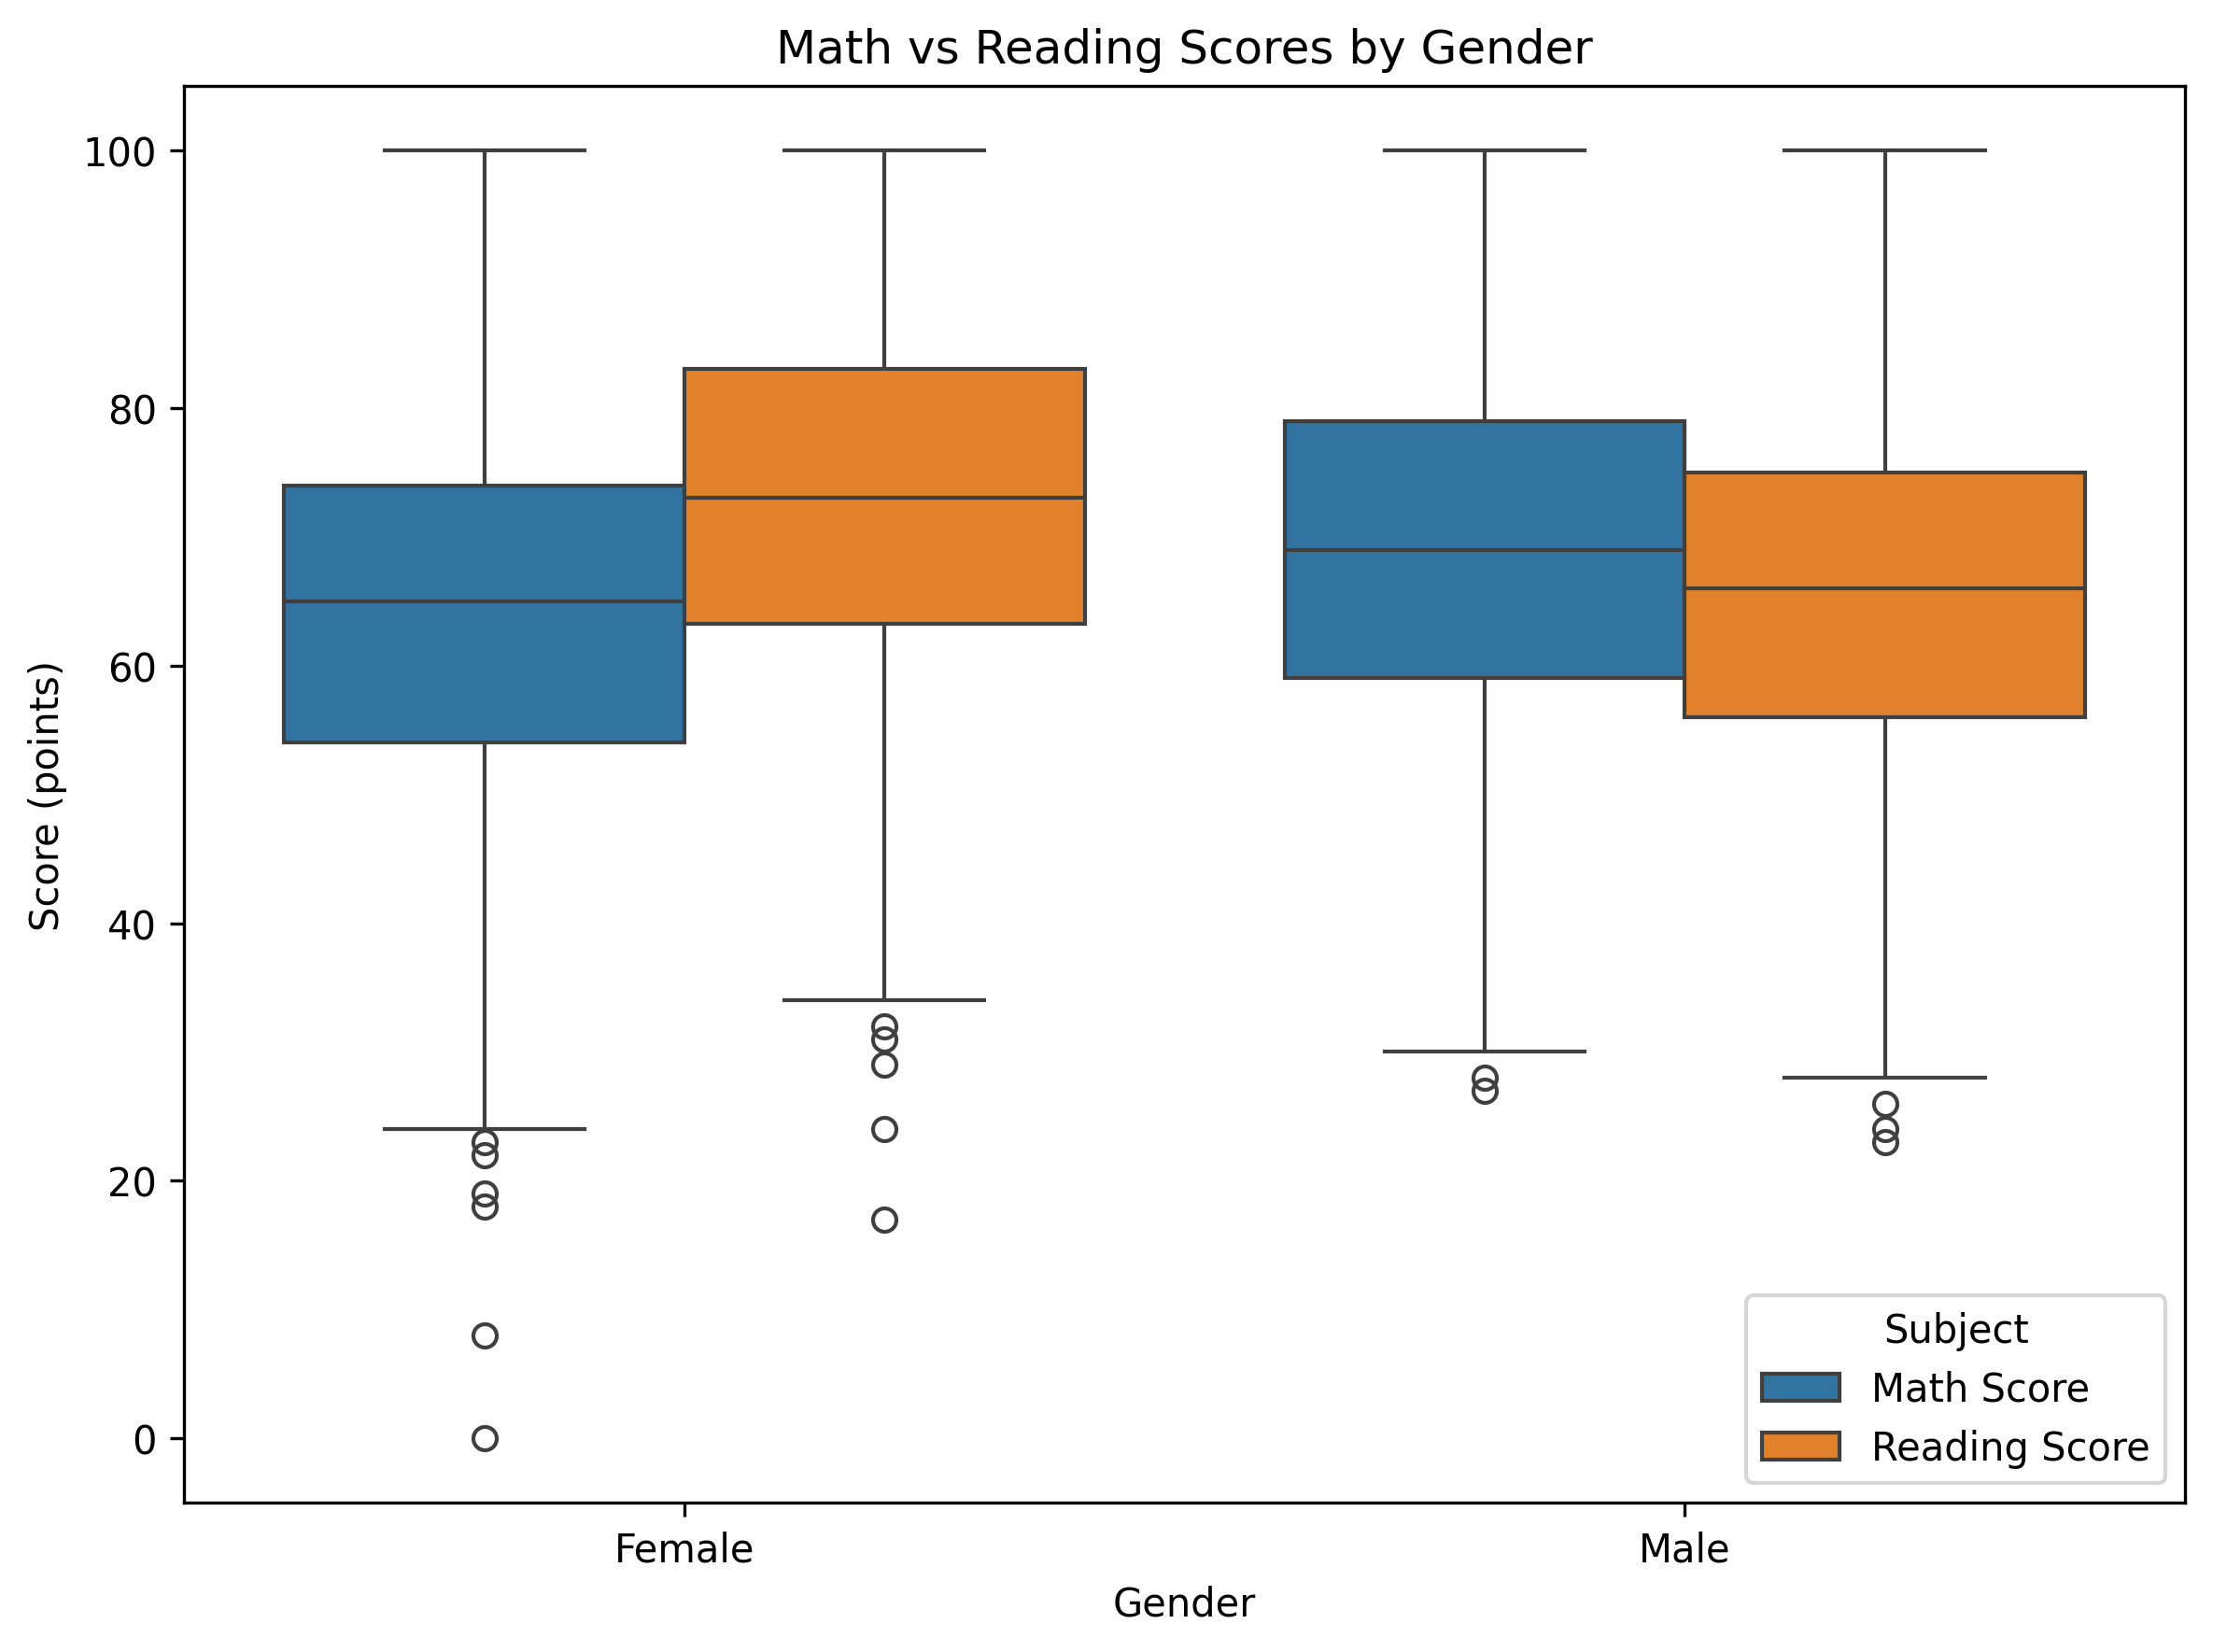

In [25]:
v1_data = df_clean_q2.melt(
    id_vars="gender",
    value_vars=["math_score", "reading_score"],
    var_name="Subject",
    value_name="Score"
)

v1_data["Subject"] = v1_data["Subject"].str.replace("_", " ").str.title()
v1_data["gender"] = v1_data["gender"].str.title()

plt.figure(figsize=(8, 6), dpi=300)

sns.boxplot(
    data=v1_data,
    x="gender",
    y="Score",
    hue="Subject"
)

plt.title("Math vs Reading Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Score (points)")
plt.legend(title="Subject")

plt.tight_layout()

plt.savefig(
    "V1_gender_score_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### B. V2 - Test prep impact on math

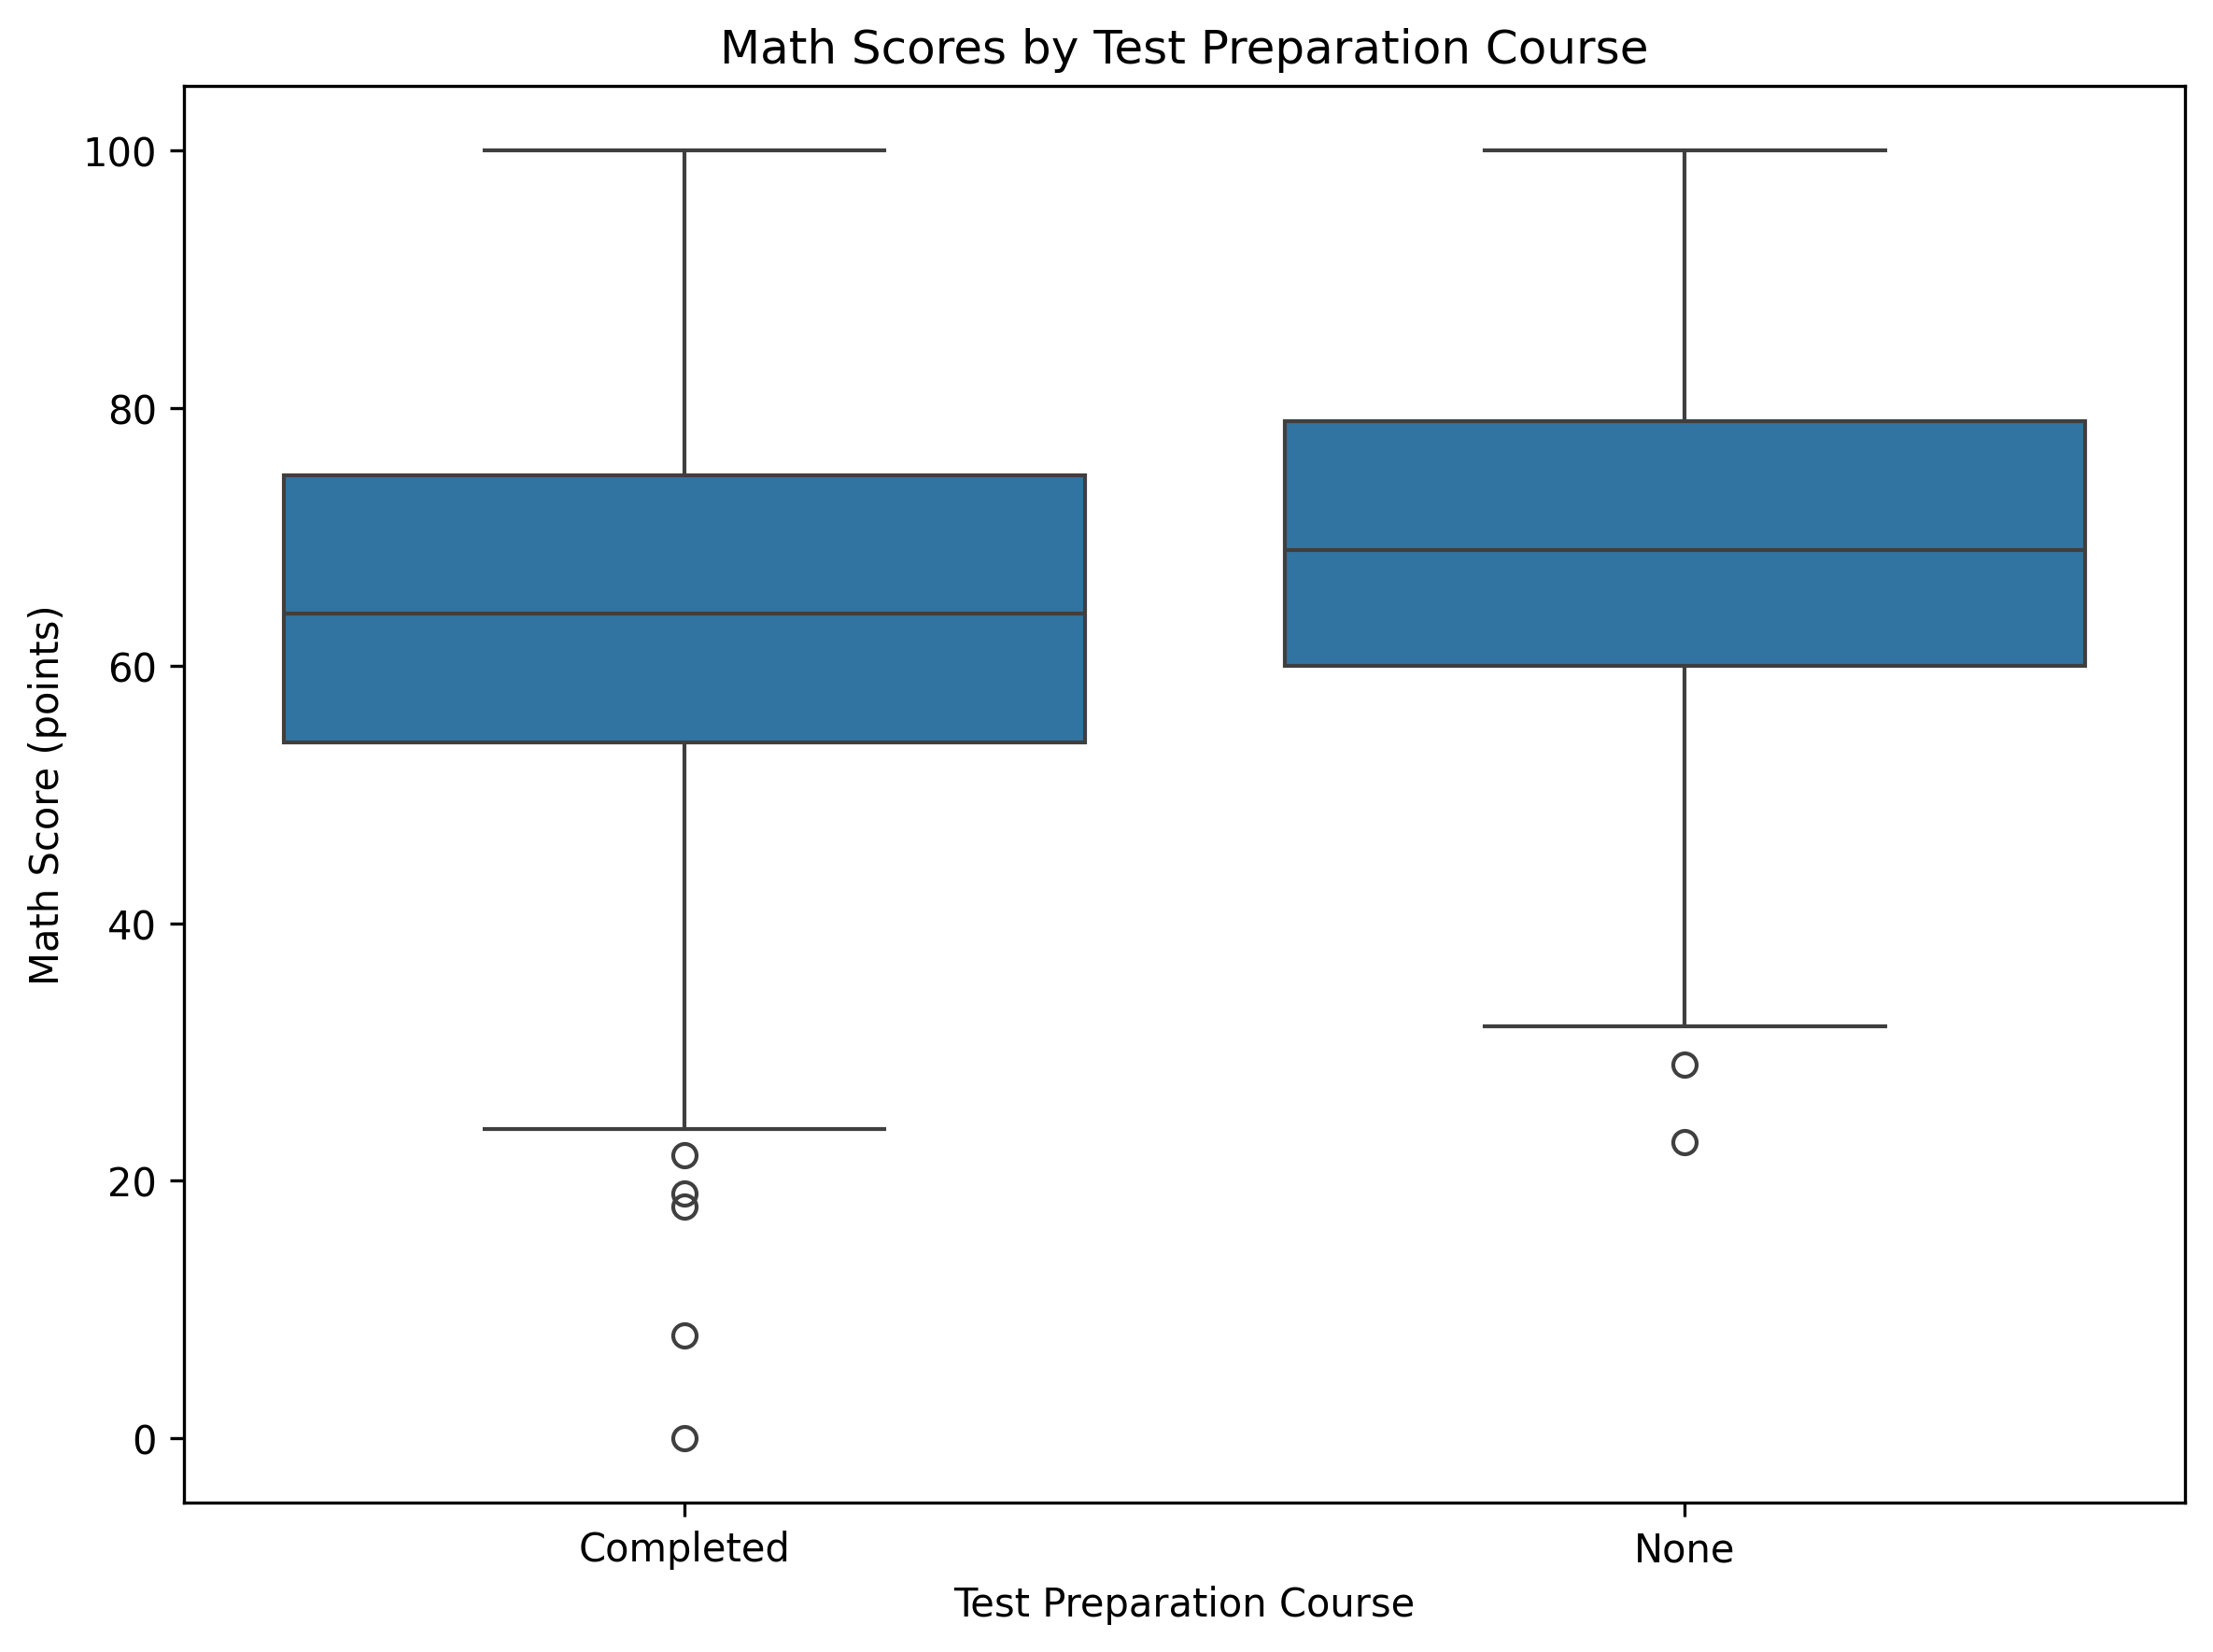

In [26]:
plt.figure(figsize=(8, 6), dpi=300)

sns.boxplot(
    data=df_clean_q2,
    x="test_prep",
    y="math_score"
)

plt.title("Math Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score (points)")

plt.xticks(
    ticks=[0, 1],
    labels=["Completed", "None"]
)

plt.tight_layout()

plt.savefig(
    "V2_test_prep_math.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### C. V3 - Lunch type and average performance

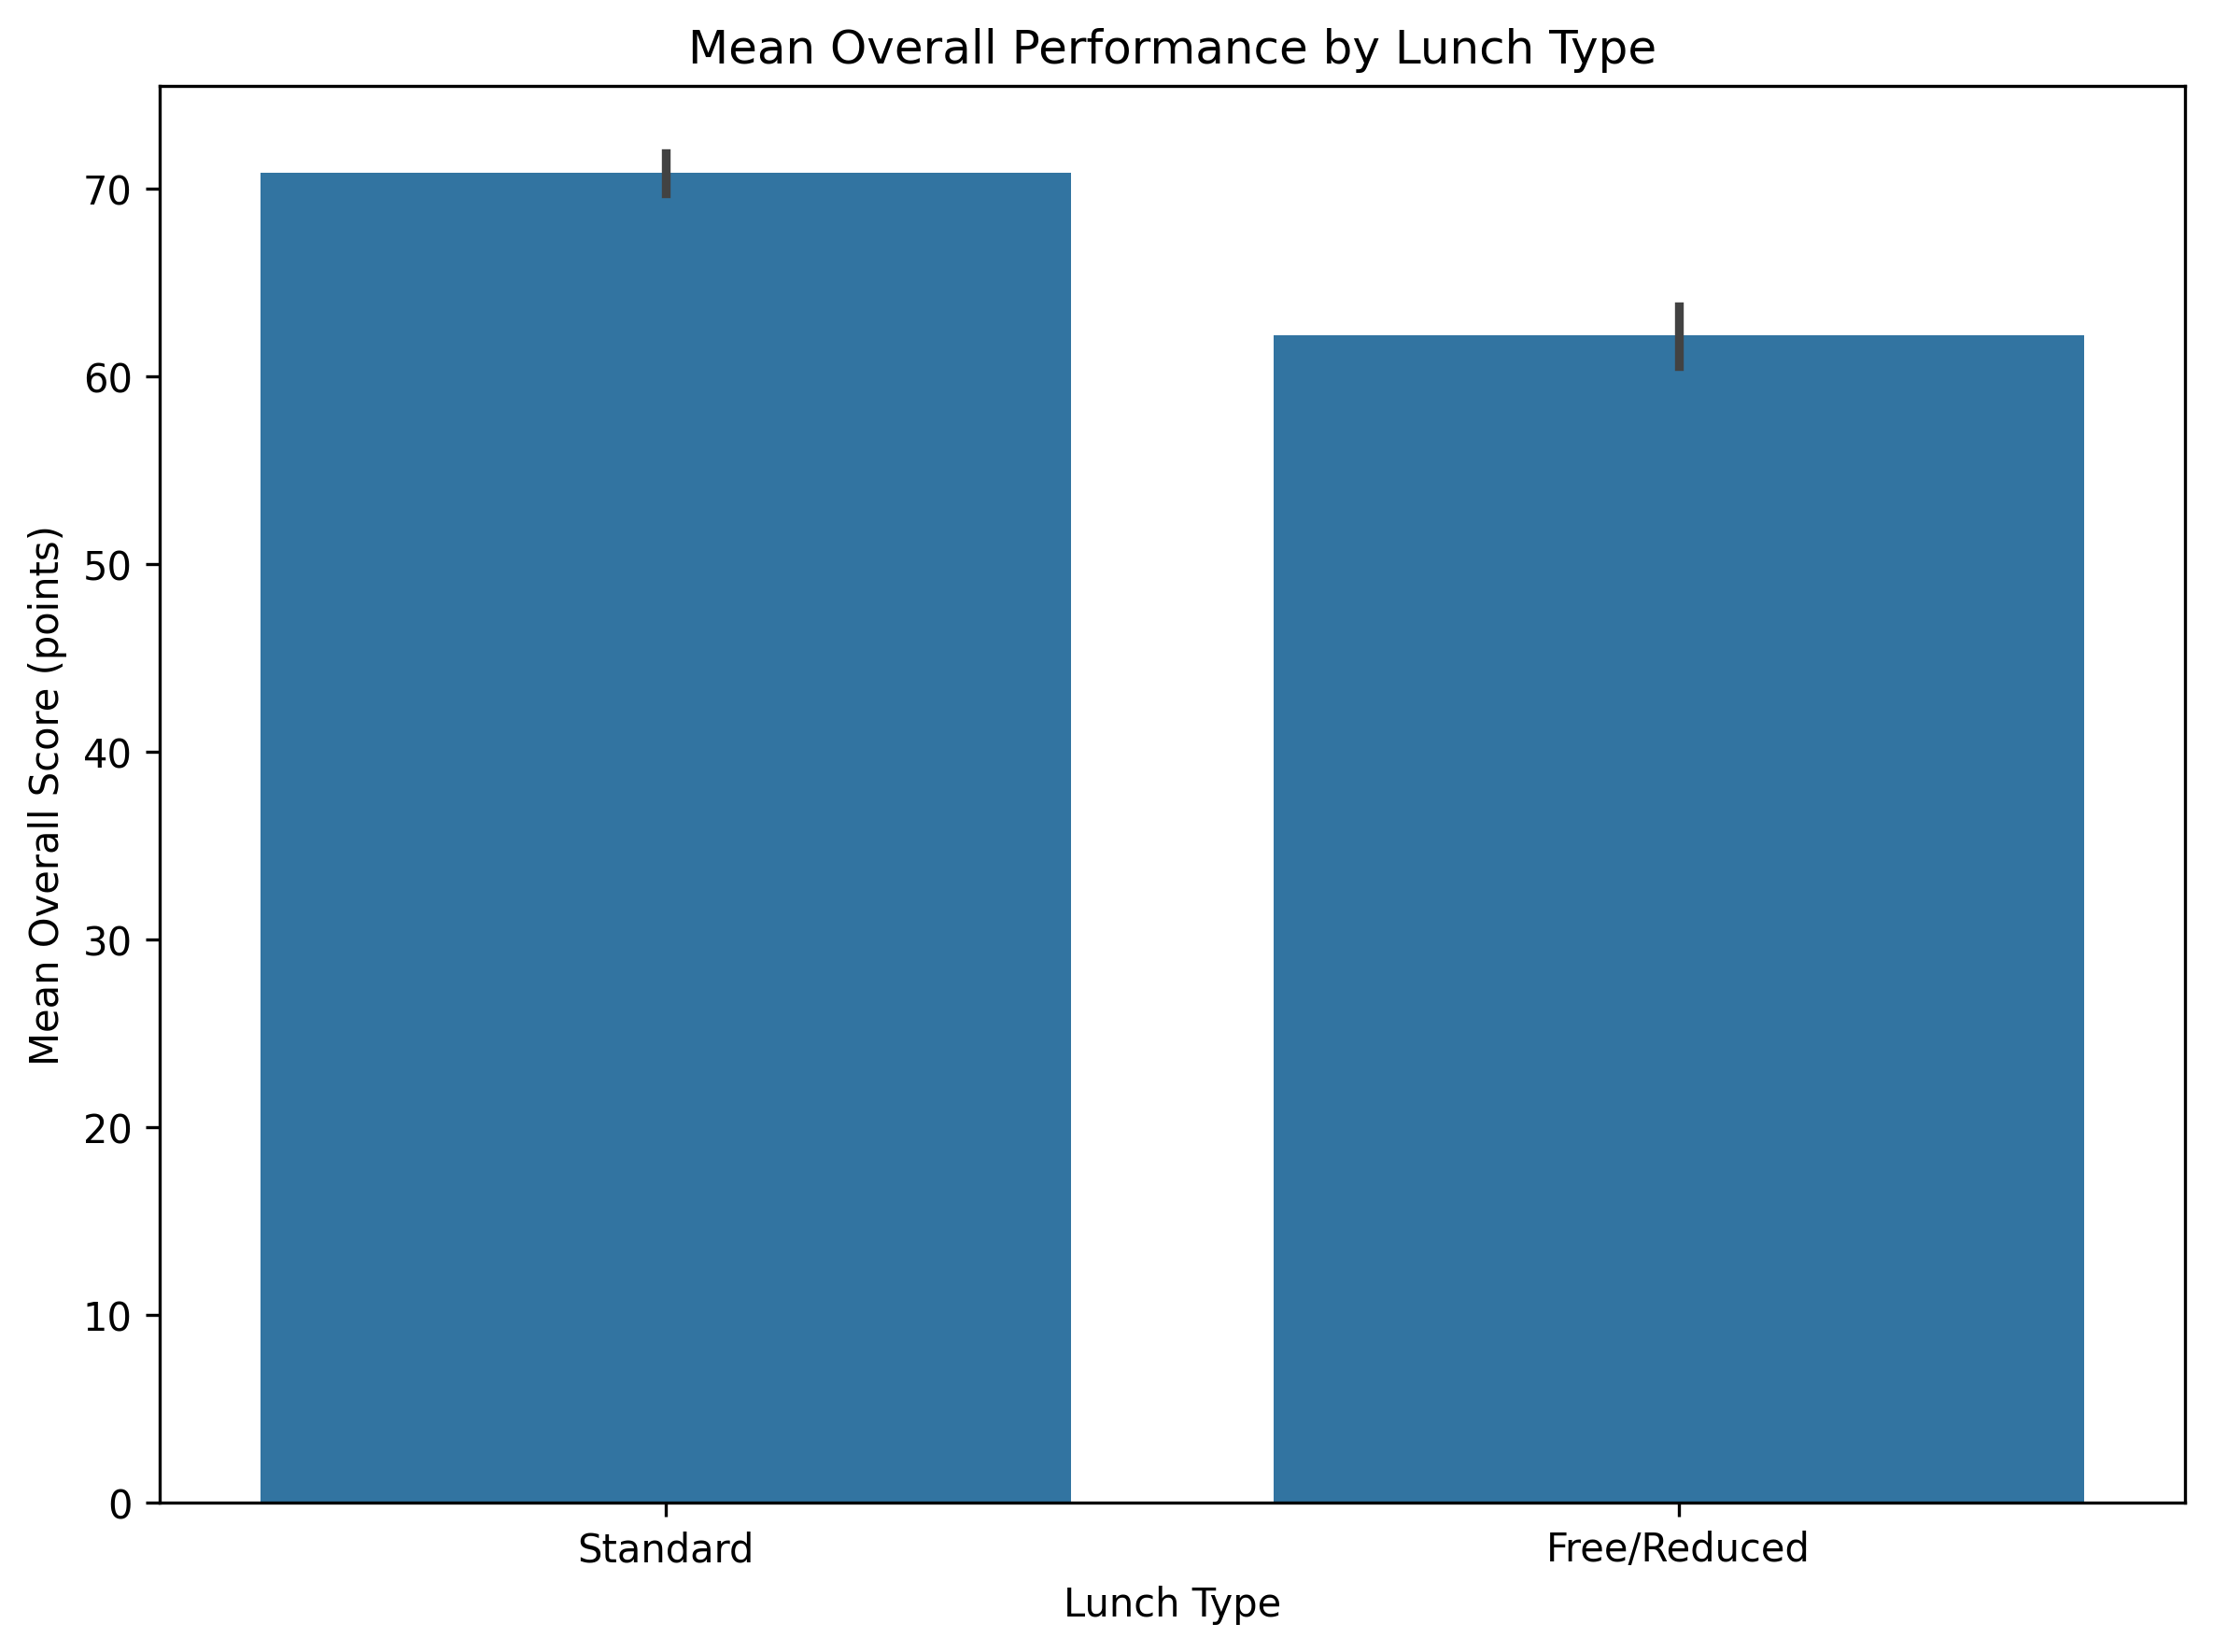

In [27]:
plt.figure(figsize=(8, 6), dpi=300)

sns.barplot(
    data=df_clean_q2,
    x="lunch",
    y="overall_avg"
)

plt.title("Mean Overall Performance by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Mean Overall Score (points)")

plt.xticks(
    ticks=[0, 1],
    labels=["Standard", "Free/Reduced"]
)

plt.tight_layout()

plt.savefig(
    "V3_lunch_overall_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### D. V4 - Subject correlations

In [28]:
correlation_matrix = df_clean_q2[
    ["math_score", "reading_score", "writing_score"]
].corr()

correlation_matrix = correlation_matrix.rename(
    index={
        "math_score": "Math Score",
        "reading_score": "Reading Score",
        "writing_score": "Writing Score"
    },
    columns={
        "math_score": "Math Score",
        "reading_score": "Reading Score",
        "writing_score": "Writing Score"
    }
)

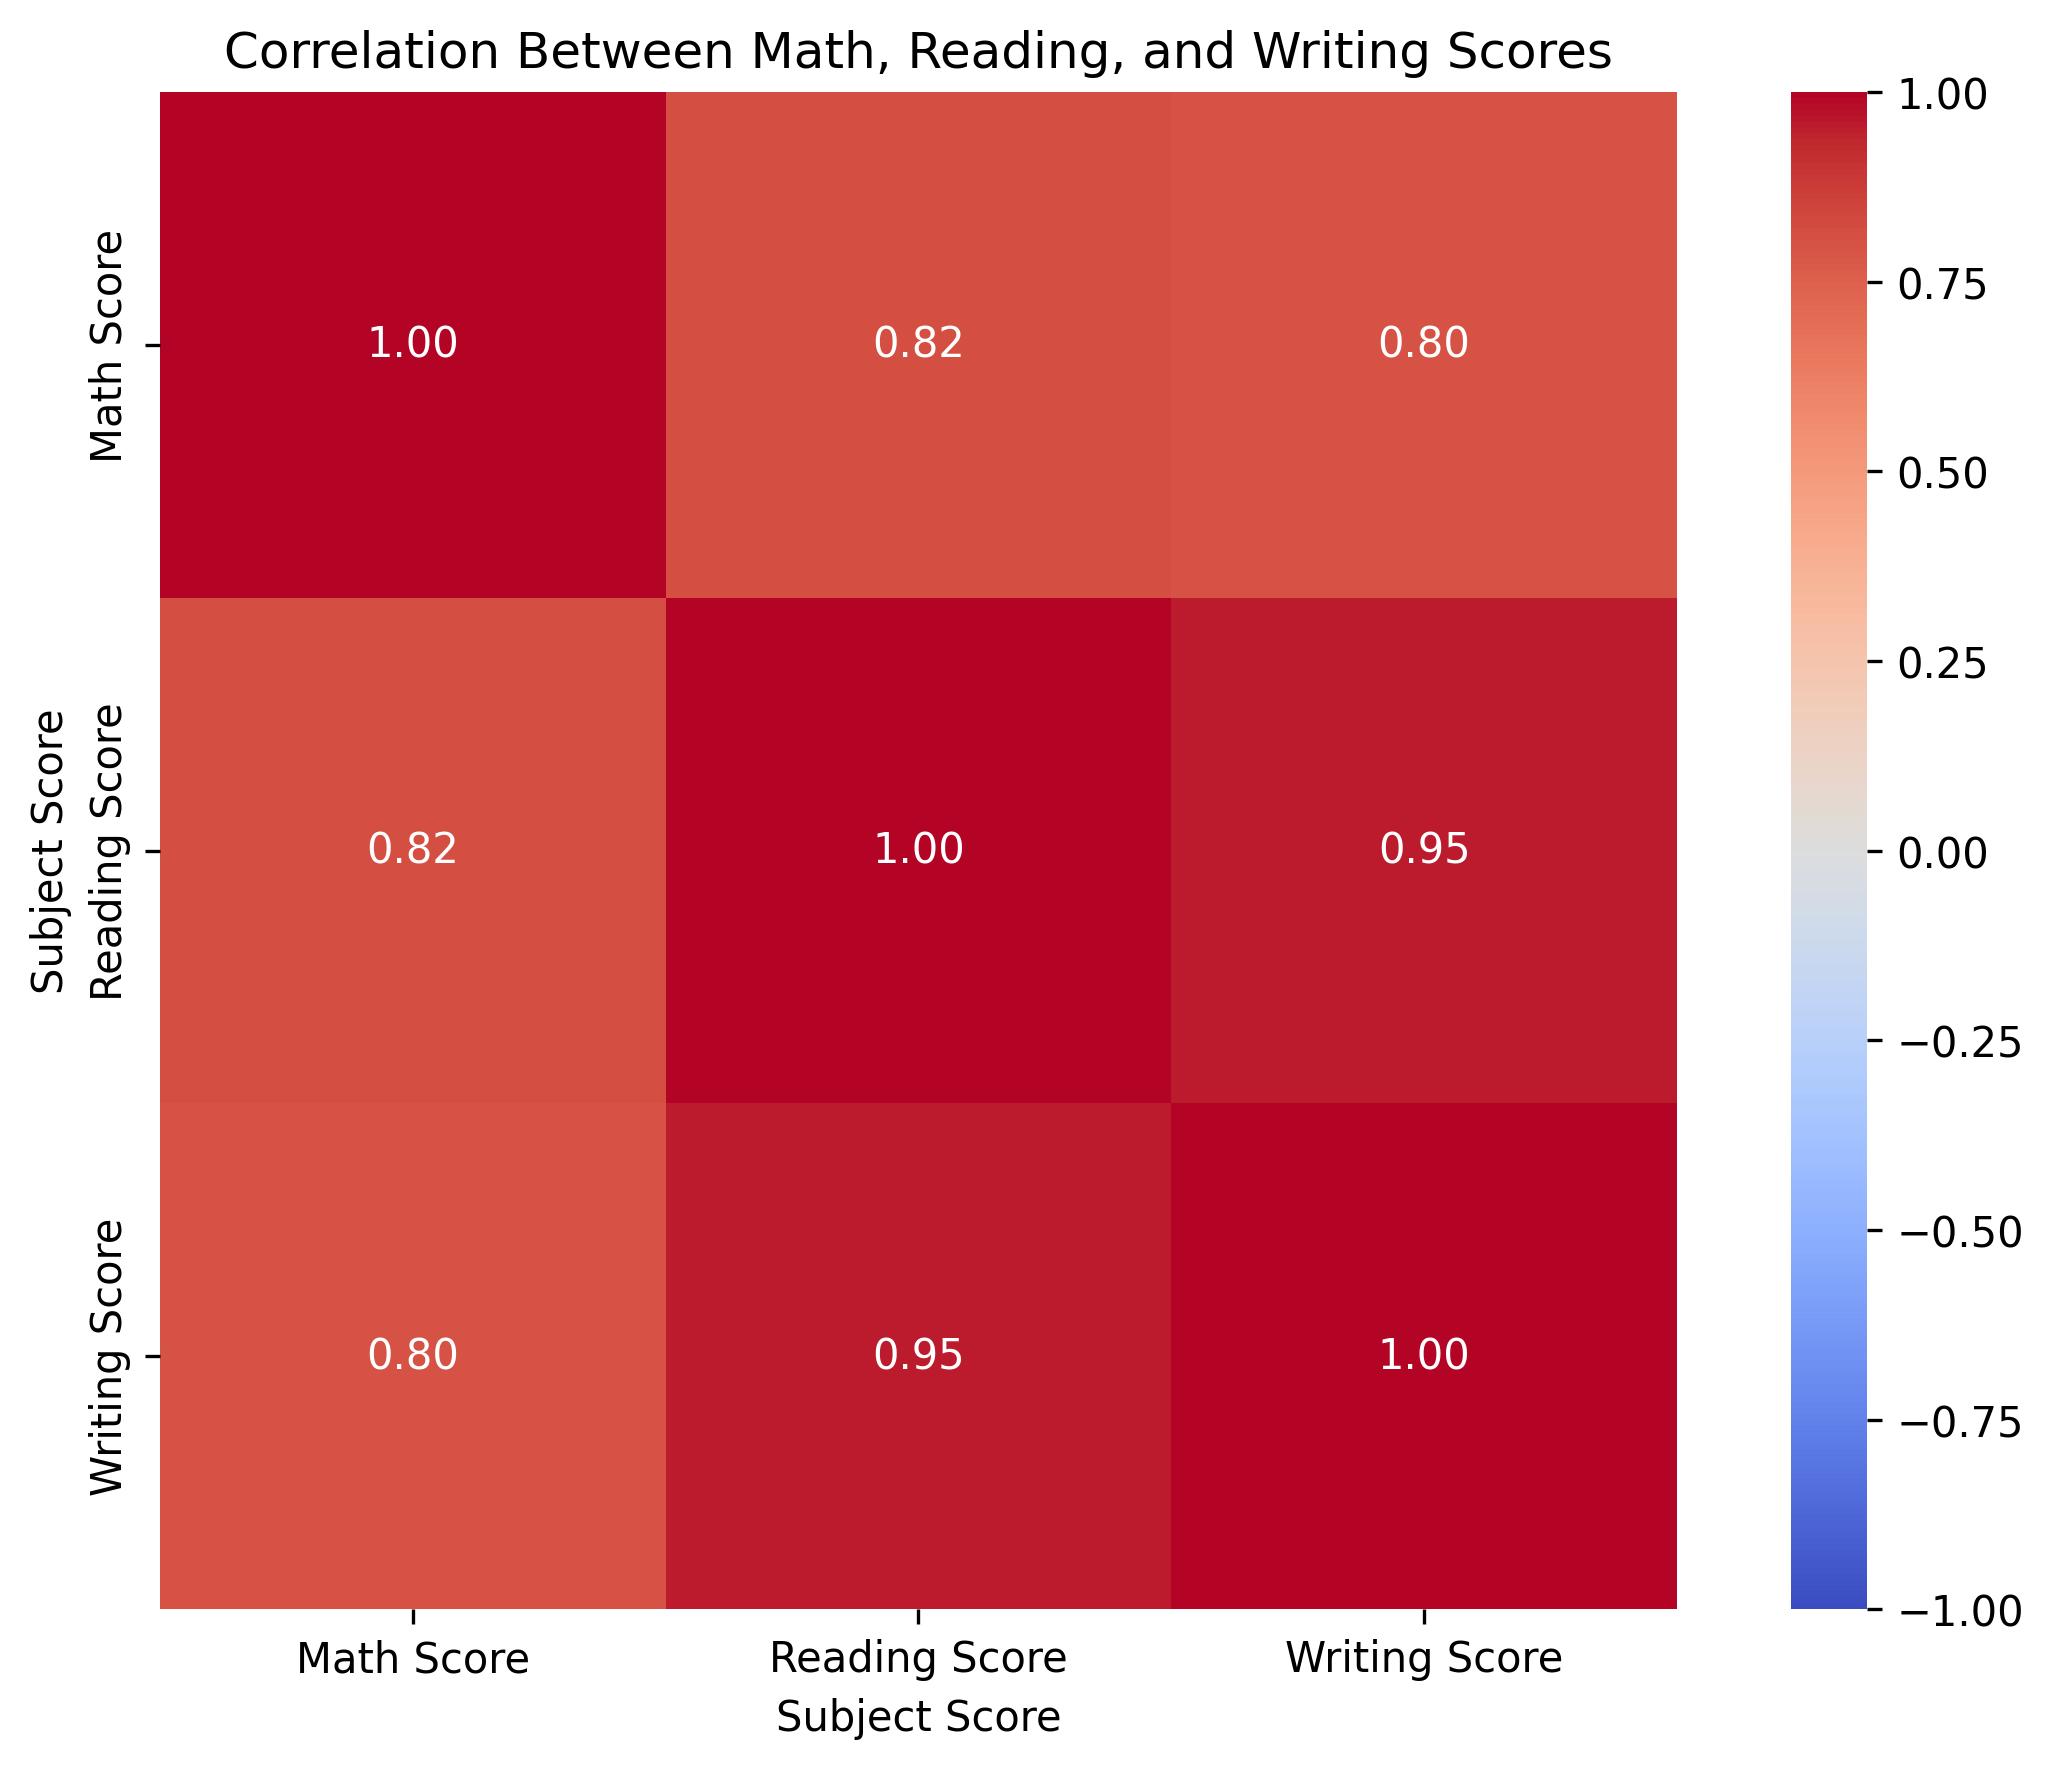

In [29]:
plt.figure(figsize=(8, 6), dpi=300)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Between Math, Reading, and Writing Scores")
plt.xlabel("Subject Score")
plt.ylabel("Subject Score")

plt.tight_layout()

plt.savefig(
    "V4_subject_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### E. V5 - Math vs reading with trend lines by test prep

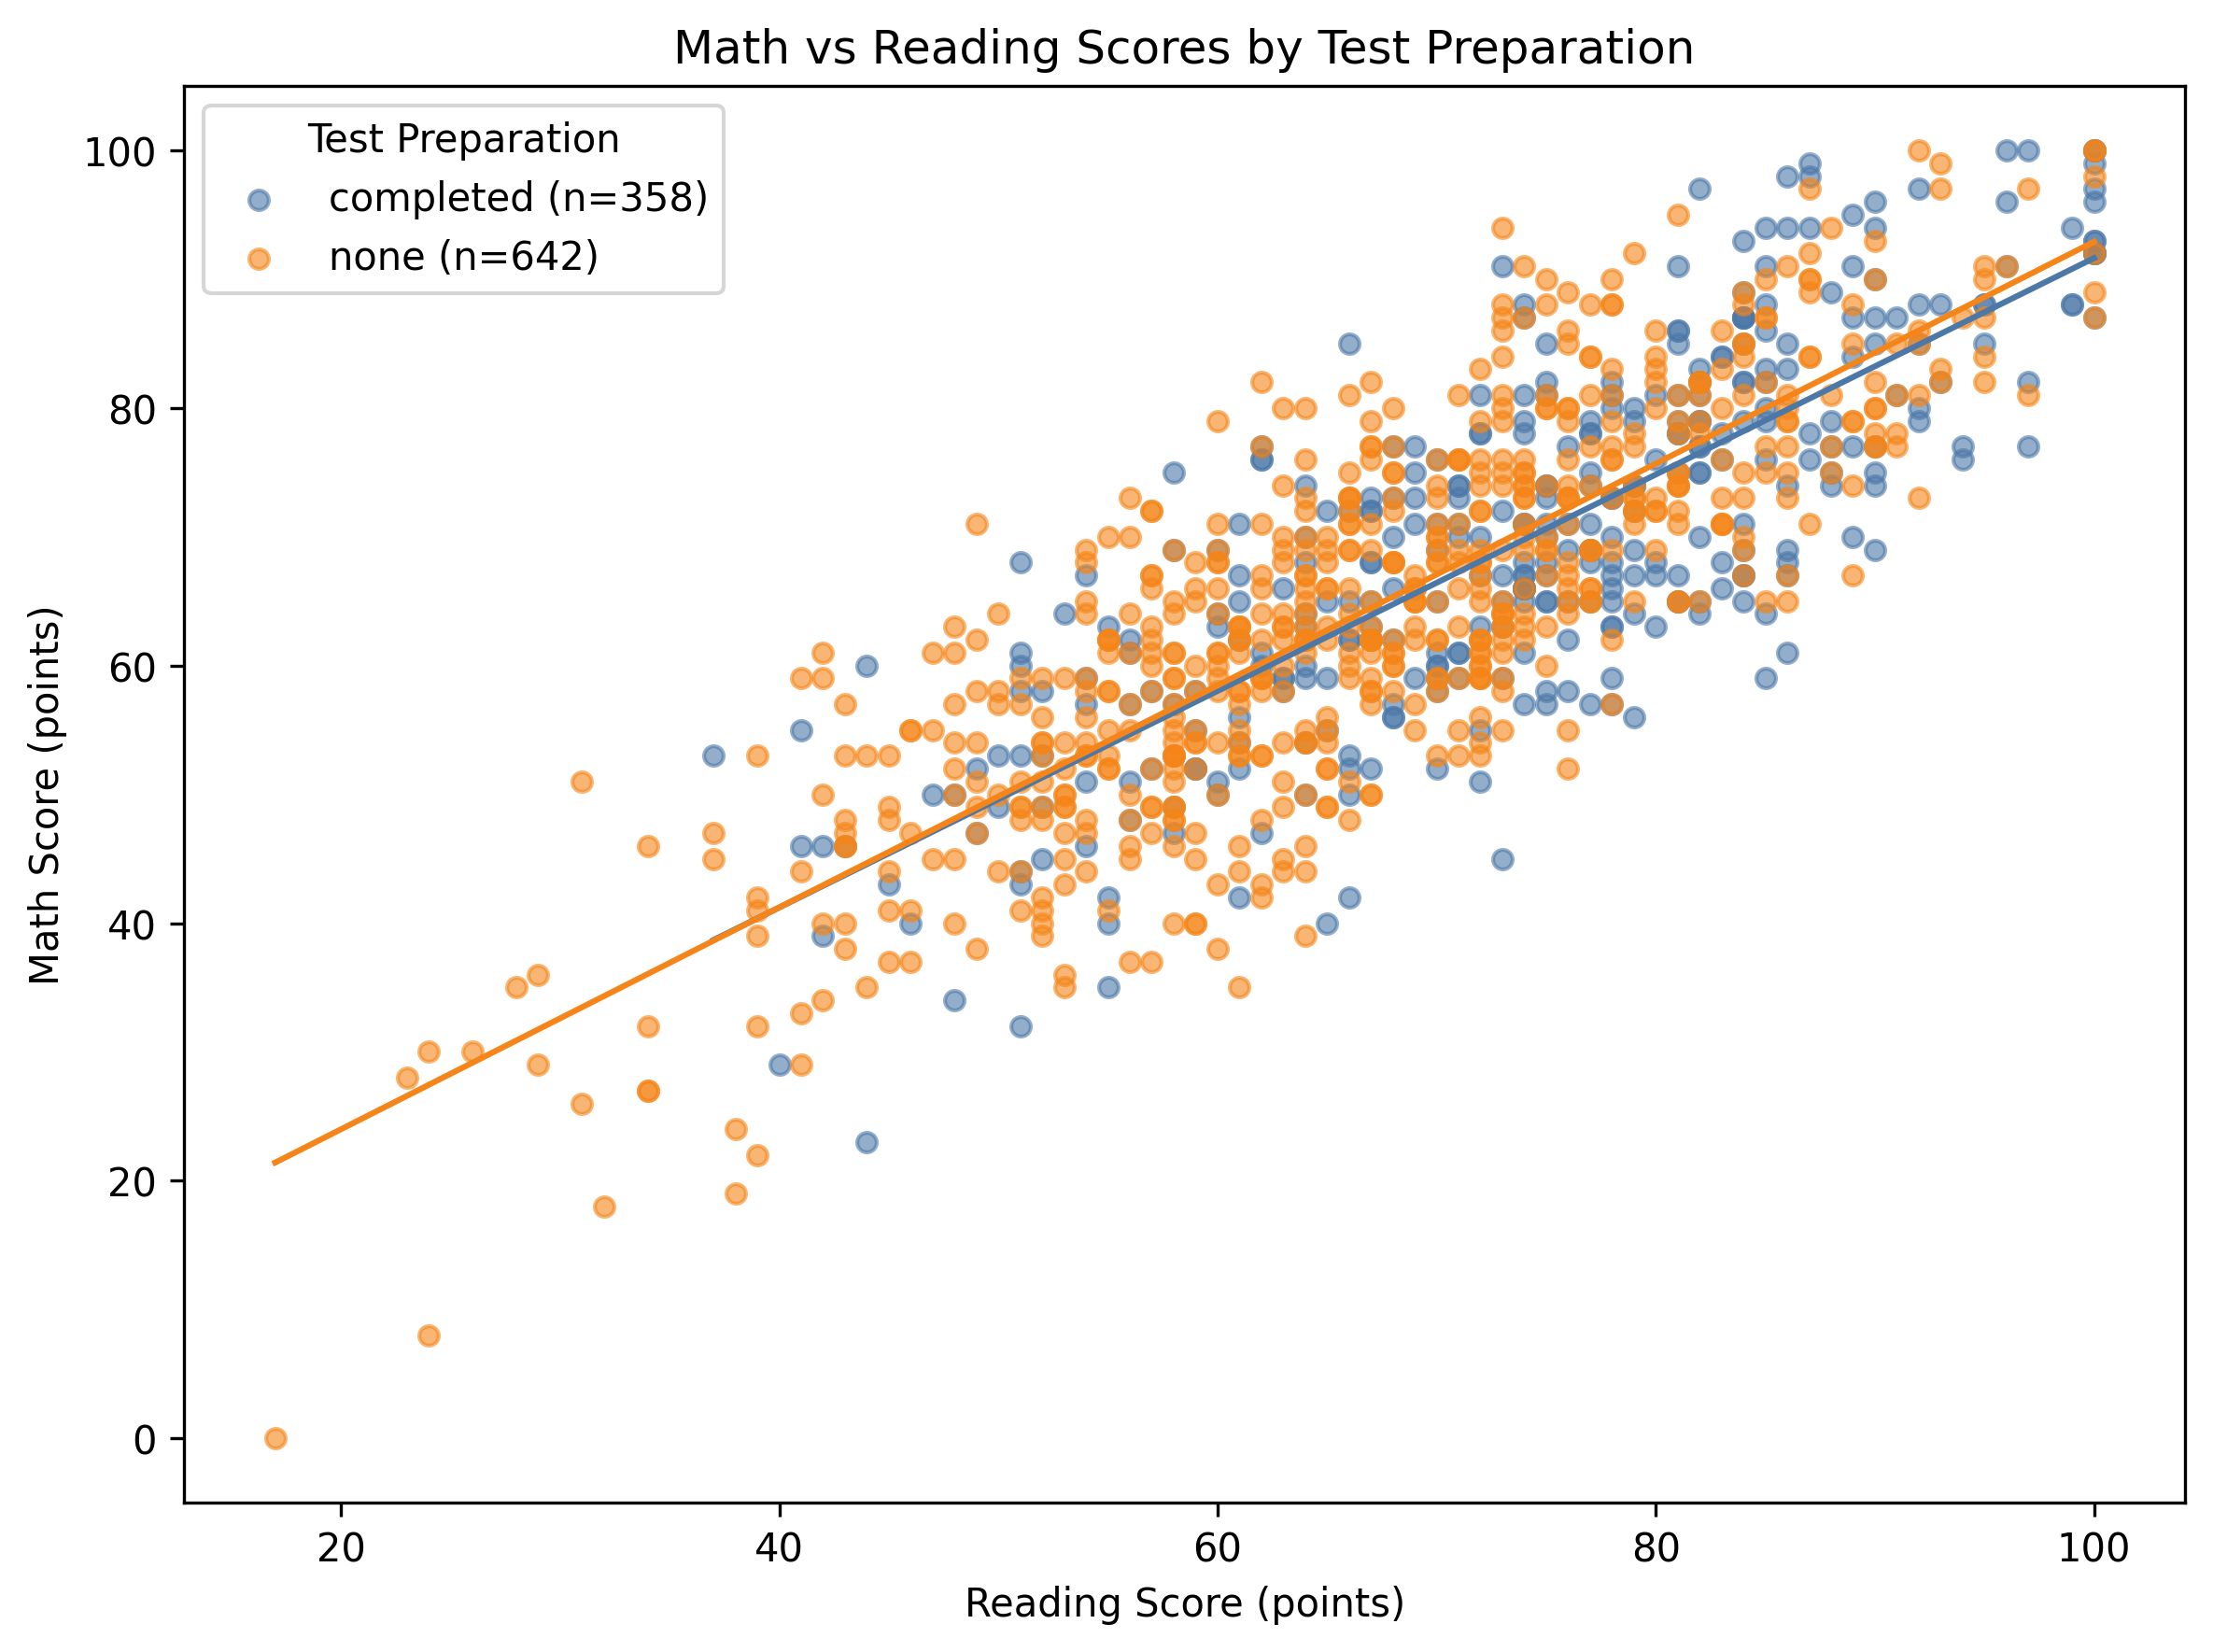

In [30]:
colors = {
    "completed": "#4C78A8",  # blue
    "none": "#F58518"        # orange
}

plt.figure(figsize=(8, 6), dpi=300)

for group in ["completed", "none"]:

    group_data = df_clean_q2[
        df_clean_q2["test_prep"] == group
    ]

    x = group_data["reading_score"]
    y = group_data["math_score"]

    plt.scatter(
        x,
        y,
        color=colors[group],
        alpha=0.6,
        s=25,
        label=f"{group} (n={len(group_data)})"
    )

    slope, intercept = np.polyfit(x, y, 1)

    x_line = np.linspace(x.min(), x.max(), 100)

    y_line = slope * x_line + intercept

    plt.plot(
        x_line,
        y_line,
        color=colors[group],
        linewidth=1.5
    )

plt.title("Math vs Reading Scores by Test Preparation")
plt.xlabel("Reading Score (points)")
plt.ylabel("Math Score (points)")
plt.legend(title="Test Preparation")
plt.tight_layout()

plt.savefig(
    "V5_math_vs_reading_test_prep.png",
    dpi=300
)

plt.show()